# Politicians Network — Data Collection
Collects politicians active during **1900–1950** from Wikipedia/Wikidata.

### Pipeline
1. Fetch top Wikipedia pageviews for 2024 (parallelised)
2. Batch-resolve Wikidata IDs (50 titles per request)
3. Filter politicians via SPARQL (bulk, not one-by-one)
4. Enrich with position, nationality, birth/death info (paginated)

### Fixes applied
- **Bug 1:** `get_all_people_ids` was fetching all humans with no political or date filter — now queries directly for politicians born or active 1900–1950, eliminating the need for a separate `filter_politicians_sparql` pass.
- **Bug 2:** Nationality was bound as `?nat` but read as `?nationalityLabel` — fixed variable names so the Wikidata label service resolves country names correctly.

In [1]:
import requests
import time
import json
import re
import pandas as pd
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timedelta
from tqdm import tqdm
import threading
import random

In [2]:
# ── Shared session & constants ────────────────────────────────────────────────
S = requests.Session()
S.headers.update({"User-Agent": "PoliticiansNetwork/1.0 (kerem.ozemre@icloud.com)"})

BASE_PAGEVIEWS = "https://wikimedia.org/api/rest_v1/metrics/pageviews/top/en.wikipedia/all-access"
BASE_WIKI      = "https://en.wikipedia.org/w/api.php"
SPARQL_URL     = "https://query.wikidata.org/sparql"

SKIP_PREFIXES = ("Special:", "Main_Page", "Wikipedia:", "Help:", "File:", "Portal:")


def get_with_retry(url, params=None, session=S, max_retries=6):
    """GET with exponential backoff on 429/5xx. Respects global adaptive delay."""
    for attempt in range(max_retries):
        try:
            r = session.get(url, params=params, timeout=30)
            if r.status_code == 429:
                wait = 2 ** attempt + random.uniform(0.5, 1.5)
                print(f"  Rate-limited, waiting {wait:.1f}s…")
                time.sleep(wait)
                continue
            r.raise_for_status()
            return r
        except requests.RequestException as e:
            if attempt == max_retries - 1:
                raise RuntimeError(f"Failed after {max_retries} retries: {url}") from e
            time.sleep(2 ** attempt)
    raise RuntimeError(f"Failed after {max_retries} retries: {url}")

## 1 — Fetch top Wikipedia pageviews (parallelised)

In [3]:
def fetch_day_views(date_str):
    """Return list of article dicts for one day (YYYY/MM/DD)."""
    url = f"{BASE_PAGEVIEWS}/{date_str}"
    try:
        r = get_with_retry(url)
        return r.json()["items"][0]["articles"]
    except Exception as e:
        print(f"  Error on {date_str}: {e}")
        return []


def get_top_pages_2024(n_days=360, max_workers=8):
    """Fetch top-1000 articles per day for n_days in 2024, parallelised."""
    start  = datetime(2024, 1, 1)
    days   = [(start + timedelta(days=i)).strftime("%Y/%m/%d") for i in range(n_days)]
    counts = defaultdict(int)

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(fetch_day_views, d): d for d in days}
        for future in tqdm(as_completed(futures), total=len(days), desc="Fetching pageviews"):
            for article in future.result():
                title = article["article"]
                if not title.startswith(SKIP_PREFIXES):
                    counts[title] += article["views"]

    sorted_pages = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    return [title for title, _ in sorted_pages]


page_views_ranked = get_top_pages_2024(n_days=360)
print(f"Unique pages collected: {len(page_views_ranked)}")
print("Top 20:", page_views_ranked[:20])

Fetching pageviews: 100%|██████████| 360/360 [00:03<00:00, 98.19it/s] 

Unique pages collected: 40460
Top 20: ['Cleopatra', 'Deaths_in_2024', 'YouTube', 'XXXTentacion', 'Pornhub', '2024_United_States_presidential_election', 'Kamala_Harris', 'Donald_Trump', '.xxx', 'Indian_Premier_League', 'Deadpool_&_Wolverine', 'Project_2025', 'ChatGPT', 'Taylor_Swift', 'Elon_Musk', '2024_Indian_general_election', '2020_United_States_presidential_election', 'United_States', 'Facebook', 'XXX_(2002_film)']


## 2 — Batch-resolve Wikidata IDs (50 titles per request)

In [4]:
def get_wikidata_ids_batch(titles):
    """
    Resolve up to 50 Wikipedia titles → Wikidata QIDs in one API call.
    Returns dict {title: qid_or_None}.
    """
    params = {
        "action":  "query",
        "titles":  "|".join(titles),
        "prop":    "pageprops",
        "ppprop":  "wikibase_item",
        "format":  "json",
    }
    r = get_with_retry(BASE_WIKI, params=params)
    pages = r.json()["query"]["pages"]

    normalised = {n["from"]: n["to"] for n in r.json()["query"].get("normalized", [])}

    result = {}
    for page in pages.values():
        qid    = page.get("pageprops", {}).get("wikibase_item")
        ptitle = page.get("title", "")
        result[ptitle] = qid

    for orig, norm in normalised.items():
        if norm in result:
            result[orig] = result[norm]
    return result


def resolve_all_qids(titles, batch_size=50, max_workers=3):
    """Resolve all titles to QIDs using parallelised batched requests."""
    title_to_qid = {}
    batches = [titles[i:i+batch_size] for i in range(0, len(titles), batch_size)]
    lock = threading.Lock()

    def fetch_batch(batch):
        time.sleep(random.uniform(0.1, 0.5))   # jitter before each request
        for attempt in range(6):
            try:
                result = get_wikidata_ids_batch(batch)
                with lock:
                    title_to_qid.update(result)
                return
            except requests.HTTPError as e:
                if e.response is not None and e.response.status_code == 429:
                    wait = 2 ** attempt + random.uniform(0.5, 1.5)
                    print(f"  Rate-limited, waiting {wait:.1f}s…")
                    time.sleep(wait)
                else:
                    raise
        print(f"  Giving up on batch after 6 retries")

    sem = threading.Semaphore(max_workers)

    def fetch_with_sem(batch):
        with sem:
            fetch_batch(batch)

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        list(tqdm(
            pool.map(fetch_with_sem, batches),
            total=len(batches),
            desc="Resolving Wikidata IDs"
        ))

    return title_to_qid


candidates = page_views_ranked[:100000]
title_to_qid = resolve_all_qids(candidates)
qids = [qid for qid in title_to_qid.values() if qid]
print(f"Resolved {len(qids)} QIDs from {len(candidates)} titles")

Resolving Wikidata IDs: 100%|██████████| 810/810 [02:11<00:00,  6.16it/s]

Resolved 74202 QIDs from 40460 titles


## 3 — Core SPARQL executor & helpers

In [5]:
HEADERS = {
    "Accept": "application/json",
    "User-Agent": "WikidataResearchBot/1.0 (kerem.ozemre@icloud.com)"
}

SESSION = requests.Session()


def run_sparql(query, retries=5, base_sleep=1.5):
    """SPARQL query using POST (avoids URI-too-long errors)."""
    for attempt in range(retries):
        try:
            r = SESSION.post(
                SPARQL_URL,
                data={"query": query},
                headers={
                    "Accept": "application/json",
                    "User-Agent": "WikidataResearchBot/1.0"
                },
                timeout=60
            )
            if r.status_code == 429:
                time.sleep(base_sleep * (2 ** attempt))
                continue
            r.raise_for_status()
            return r.json()
        except Exception as e:
            if attempt == retries - 1:
                raise RuntimeError(f"SPARQL failed: {e}")
            time.sleep(base_sleep * (2 ** attempt))
    raise RuntimeError("SPARQL query failed")


# Alias kept for compatibility
run_sparql_with_retry = run_sparql


def chunked(lst, size):
    for i in range(0, len(lst), size):
        yield lst[i:i + size]


def parse_wikidata_date(raw):
    """Extract YYYY-MM-DD from Wikidata timestamps."""
    if not raw:
        return None
    m = re.match(r"[+-]?(\d{4}-\d{2}-\d{2})", raw)
    return m.group(1) if m else None


def extract_qid(uri):
    return uri.split("/")[-1]

## 4 — Fetch politicians (1900–1950) directly via SPARQL

> **Fix for Bug 1:** The old pipeline fetched *all humans* with no date or occupation filter, then tried to filter for politicians afterwards. With 3 000 random humans, almost none were politicians — hence only Saddam Hussein slipping through.
>
> The query below requests people whose occupation is politician (`P106 = Q82955`) **and** whose birth or death falls within 1900–1950, so the `filter_politicians_sparql` step is no longer needed.

In [6]:
def make_politicians_query(limit=1000, offset=0):
    return f"""
    SELECT DISTINCT ?person WHERE {{
      ?person wdt:P31 wd:Q5 ;              # human
              wdt:P106 wd:Q82955 ;        # politician
              wdt:P27 wd:Q30 .            # US citizenship

      OPTIONAL {{ ?person wdt:P569 ?birth. }}
      OPTIONAL {{ ?person wdt:P570 ?death. }}
      OPTIONAL {{ 
        ?person wdt:P19 ?birthPlace . 
        ?birthPlace wdt:P131* ?state .   # located in admin entity
        ?state wdt:P31 wd:Q35657 .       # instance of US state
      }}

      FILTER(
        # born before end of window
        (BOUND(?birth) && YEAR(?birth) <= 2024)
        &&
        # alive during or after 1980
        (
          !BOUND(?death) || YEAR(?death) >= 1980
        )
      )
    }}
    LIMIT {limit}
    OFFSET {offset}
    """

def get_politician_ids(max_people=3000, page_size=500):
    """
    Paginate through Wikidata and return QID URIs for politicians
    born or active in 1900-1950.
    """
    ids = []
    offset = 0

    while len(ids) < max_people:
        query = make_politicians_query(limit=page_size, offset=offset)
        data  = run_sparql_with_retry(query)

        bindings = data["results"]["bindings"]
        if not bindings:
            break

        batch = [b["person"]["value"] for b in bindings]
        ids.extend(batch)
        offset += page_size
        print(f"Collected {len(ids)} politicians")
        time.sleep(1)

    return ids[:max_people]

## 5 — Fetch details (position, nationality, dates)

> **Fix for Bug 2:** The old query bound nationality as `?nat` but the Python parser read `?nationalityLabel`. Because `?nat` was never exposed to the label service correctly, country names came back as raw QIDs (e.g. `Q36` instead of `Poland`).
>
> The fix: bind nationality to `?nat` *and* select it so the label service generates `?natLabel`, then read that in Python.

In [7]:
def make_details_query(person_ids):
    values = " ".join(f"wd:{p.split('/')[-1]}" for p in person_ids)

    return f"""
    SELECT
      ?person
      ?personLabel
      ?positionLabel
      ?start
      ?end
      ?natLabel
      ?birth
      ?death
      ?partyLabel
      ?genderLabel
      ?educationLabel
      ?stateLabel
      ?article
    WHERE {{
      VALUES ?person {{ {values} }}

      ?person p:P39 ?statement .
      ?statement ps:P39 ?position .
      OPTIONAL {{ ?statement pq:P580 ?start. }}
      OPTIONAL {{ ?statement pq:P582 ?end. }}

      OPTIONAL {{ ?person wdt:P27 ?nat. }}
      OPTIONAL {{ ?person wdt:P569 ?birth. }}
      OPTIONAL {{ ?person wdt:P570 ?death. }}

      OPTIONAL {{ ?person wdt:P102 ?party. }}
      OPTIONAL {{ ?person wdt:P21 ?gender. }}
      OPTIONAL {{ ?person wdt:P69 ?education. }}

      OPTIONAL {{
        ?person wdt:P19 ?birthPlace .
        ?birthPlace wdt:P131* ?state .
      }}

      # Wikipedia English article URL — used as text-analysis target
      OPTIONAL {{
        ?article schema:about ?person ;
                 schema:isPartOf <https://en.wikipedia.org/> .
      }}

      SERVICE wikibase:label {{
        bd:serviceParam wikibase:language "en".
      }}
    }}
    """

def safe(item, key):
    return item.get(key, {}).get("value")

def fetch_details(person_ids, batch_size=50):
    """
    Fetch enriched details for a list of person URIs/QIDs.
    Reads ?natLabel (not ?nationalityLabel) for country names.
    Includes ?article — the English Wikipedia URL for text analysis.
    """
    rows = []

    for i, chunk in enumerate(chunked(person_ids, batch_size), 1):
        print(f"Fetching batch {i} ({len(chunk)} people)")

        query = make_details_query(chunk)
        data  = run_sparql_with_retry(query)

        for item in data["results"]["bindings"]:
            rows.append({
                "wikidata":    extract_qid(item["person"]["value"]),
                "name":        item.get("personLabel", {}).get("value"),
                "position":    item.get("positionLabel", {}).get("value"),
                "start":       parse_wikidata_date(item.get("start", {}).get("value")),
                "end":         parse_wikidata_date(item.get("end", {}).get("value")),
                "nationality": item.get("natLabel", {}).get("value"),
                "birth_date":  parse_wikidata_date(item.get("birth", {}).get("value")),
                "death_date":  parse_wikidata_date(item.get("death", {}).get("value")),
                "party":       item.get("partyLabel", {}).get("value"),
                "gender":      item.get("genderLabel", {}).get("value"),
                "education":   item.get("educationLabel", {}).get("value"),
                "state":       item.get("stateLabel", {}).get("value"),
                # Wikipedia article URL — suitable for scraping / text analysis
                "wikipedia_url": item.get("article", {}).get("value"),
            })

        time.sleep(1.5)

    return rows


## 6 — Politician link degree

For each politician we count how many outgoing Wikipedia links on their page point to **another politician** (P106 = Q82955), regardless of whether that person is in our 3 000-person dataset. This gives a "degree" score — a rough proxy for how well-connected or historically prominent the person is.

### Approach
1. Use the Wikipedia API (`prop=links`) to fetch all internal wiki-links from the politician's page, in batches of 500 (the API maximum).
2. Resolve those linked titles to Wikidata QIDs via the same batch method used in Step 2.
3. Run a SPARQL VALUES query to check which resolved QIDs have occupation = politician.
4. The degree of each politician = count of politician-links found on their page.

Steps 2–3 are cached across all politicians so each Wikipedia title and each QID is only looked up once.

In [8]:
# ── Rate-limit governor ────────────────────────────────────────────────────────
# A single semaphore caps how many threads hit Wikipedia simultaneously.
# When any thread gets a 429, it sets a global backoff so ALL threads pause.

_WIKI_SEM       = threading.Semaphore(4)   # max 4 concurrent Wikipedia requests
_BACKOFF_LOCK   = threading.Lock()
_BACKOFF_UNTIL  = 0.0                      # epoch-time: threads sleep until this


def _wait_for_backoff():
    """Block until the global backoff window has passed."""
    global _BACKOFF_UNTIL
    with _BACKOFF_LOCK:
        target = _BACKOFF_UNTIL
    remaining = target - time.monotonic()
    if remaining > 0:
        time.sleep(remaining)


def _set_backoff(seconds):
    """Extend the global backoff window (takes the maximum)."""
    global _BACKOFF_UNTIL
    with _BACKOFF_LOCK:
        _BACKOFF_UNTIL = max(_BACKOFF_UNTIL, time.monotonic() + seconds)


# ── Step 6a: fetch all outgoing Wikipedia links from a page ───────────────────

def get_page_links(title):
    """Fetch all outgoing Wikipedia links for a title, one private session per call."""
    session = requests.Session()
    session.headers.update({"User-Agent": "PoliticiansNetwork/1.0 (kerem.ozemre@icloud.com)"})

    links  = []
    params = {
        "action":      "query",
        "titles":      title,
        "prop":        "links",
        "pllimit":     "500",
        "plnamespace": "0",
        "format":      "json",
    }
    while True:
        r    = get_with_retry(BASE_WIKI, params=params, session=session)
        data = r.json()
        for page in data.get("query", {}).get("pages", {}).values():
            for lk in page.get("links", []):
                links.append(lk["title"])
        cont = data.get("continue", {})
        if not cont:
            break
        params["plcontinue"] = cont["plcontinue"]
        time.sleep(0.2)   # pause between pagination calls

    return links


# ── Step 6b: resolve titles → QIDs (thread-safe cache) ────────────────────────

_title_lock = threading.Lock()
_qid_lock   = threading.Lock()


def resolve_titles_to_qids_cached(titles, cache, batch_size=50):
    with _title_lock:
        uncached = [t for t in titles if t not in cache]
    for i in range(0, len(uncached), batch_size):
        batch  = uncached[i:i + batch_size]
        result = get_wikidata_ids_batch(batch)
        with _title_lock:
            cache.update(result)
        time.sleep(0.1)
    with _title_lock:
        return {t: cache.get(t) for t in titles}


# ── Step 6c: check which QIDs are politicians (thread-safe cache) ─────────────

def filter_politician_qids_cached(qids, cache, batch_size=200):
    with _qid_lock:
        unchecked = [q for q in qids if q not in cache["seen"]]
    for i in range(0, len(unchecked), batch_size):
        batch  = unchecked[i:i + batch_size]
        values = " ".join(f"wd:{q}" for q in batch)
        query  = f"""
        SELECT ?person WHERE {{
          VALUES ?person {{ {values} }}
          ?person wdt:P106 wd:Q82955 .
        }}
        """
        data  = run_sparql_with_retry(query)
        found = [item["person"]["value"].split("/")[-1]
                 for item in data["results"]["bindings"]]   # list, not set
        with _qid_lock:
            cache["politicians"].update(found)
            cache["seen"].update(batch)
        time.sleep(0.5)
    with _qid_lock:
        return cache["politicians"]


# ── Step 6d: compute degree — parallelised with rate-limit protection ──────────

def _process_one(title, qid, title_qid_cache, politician_cache):
    """Worker: returns (qid, degree, neighbor_list)."""
    try:
        linked_titles = get_page_links(title)
    except Exception as e:
        print(f"  Could not fetch links for '{title}': {e}")
        return qid, None, []

    if not linked_titles:
        return qid, 0, []

    t2q         = resolve_titles_to_qids_cached(linked_titles, title_qid_cache)
    linked_qids = [q for q in t2q.values() if q]

    if not linked_qids:
        return qid, 0, []

    politician_set = filter_politician_qids_cached(linked_qids, politician_cache)
    pol_qids       = [q for q in linked_qids if q in politician_set]

    return qid, len(pol_qids), pol_qids


def compute_politician_degrees(name_to_qid):
    """
    Serial degree computation with adaptive throttling.
    Parallelism was causing cascading 429s — serial + smart delay is faster overall.
    """
    title_qid_cache  = {}
    politician_cache = {"seen": set(), "politicians": set()}
    degrees          = {}
    neighbors        = {}
    
    # Adaptive delay — increases on 429, decreases on success
    delay = 0.3
    
    items = list(name_to_qid.items())

    for idx, (title, qid) in enumerate(tqdm(items, desc="Computing degrees"), 1):
        for attempt in range(6):
            try:
                linked_titles = get_page_links(title)
                delay = max(0.1, delay * 0.95)   # slowly recover speed on success
                break
            except Exception as e:
                if "429" in str(e):
                    delay = min(30, delay * 2)
                    print(f"  429 on '{title}' — slowing to {delay:.1f}s delay")
                    time.sleep(delay)
                elif attempt == 5:
                    print(f"  Giving up on '{title}': {e}")
                    linked_titles = []
                    break
                else:
                    time.sleep(2 ** attempt)

        if not linked_titles:
            degrees[qid]   = 0
            neighbors[qid] = []
        else:
            t2q            = resolve_titles_to_qids_cached(linked_titles, title_qid_cache)
            linked_qids    = [q for q in t2q.values() if q]
            politician_set = filter_politician_qids_cached(linked_qids, politician_cache) if linked_qids else set()
            pol_qids       = [q for q in linked_qids if q in politician_set]
            degrees[qid]   = len(pol_qids)
            neighbors[qid] = pol_qids

        time.sleep(delay)   # adaptive inter-request delay

        if idx % 50 == 0:
            print(f"  [{idx}/{len(items)}] delay={delay:.2f}s | "
                  f"cache: {len(title_qid_cache)} titles, "
                  f"{len(politician_cache['seen'])} QIDs checked")

    return degrees, neighbors

## 7 — End-to-end pipeline

In [11]:
def run_pipeline(max_people=100):
    print("Step 1: Fetching politician IDs (1900–1950)…")
    politician_ids = get_politician_ids(max_people=max_people)
    print(f"Total politicians found: {len(politician_ids)}")

    print("\nStep 2: Fetching details (position, nationality, dates)…")
    rows = fetch_details(politician_ids)
    if not rows:
        print("WARNING: No detail rows returned.")
        return pd.DataFrame()

    df = pd.DataFrame(rows)


    # print("\nStep 3: Computing politician link degrees…")

    # unique = (
    #     df[df["name"].notna()][["name", "wikidata"]]
    #     .drop_duplicates(subset="wikidata")
    # )
    # name_to_qid = dict(zip(unique["name"], unique["wikidata"]))

    # degrees,neighbours = compute_politician_degrees(name_to_qid)

    # # Merge degree back onto df (one degree per unique QID)
    # df["degree"] = df["wikidata"].map(degrees)
    # df["connections"] = df["wikidata"].map(neighbours)

    print(f"\nDone. {len(df)} rows, {df['wikidata'].nunique()} unique politicians.")
    return df


df = run_pipeline(max_people=300)

Step 1: Fetching politician IDs (1900–1950)…
Collected 500 politicians
Total politicians found: 300

Step 2: Fetching details (position, nationality, dates)…
Fetching batch 1 (50 people)
Fetching batch 2 (50 people)
Fetching batch 3 (50 people)
Fetching batch 4 (50 people)
Fetching batch 5 (50 people)
Fetching batch 6 (50 people)

Done. 27607 rows, 270 unique politicians.


In [12]:
#Remove duplicates
POSITION_RANK = {
    "President of the United States": 1,
    "Vice President of the United States": 2,
    "Secretary of State": 3,
    "Secretary of Defense": 4,
    "Attorney General of the United States": 5,
    "Secretary of the Treasury": 6,
    "White House Chief of Staff": 7,
    "United States Senator": 8,
    "Speaker of the House of Representatives": 9,
    "House Majority Leader": 10,
    "Senate Majority Leader": 10,
    "United States Representative": 11,
    "Governor": 12,
    "Ambassador": 13,
    "Lieutenant Governor": 14,
    "State Senator": 15,
    "State Representative": 16,
    "Mayor": 17,
}

def position_priority(pos):
    if pos is None:
        return 999
    # exact match first
    if pos in POSITION_RANK:
        return POSITION_RANK[pos]
    # partial match fallback — catches "Governor of California" etc.
    for key, rank in POSITION_RANK.items():
        if key.lower() in pos.lower():
            return rank
    return 998   # known position but not in our list — still beats None

df["position_rank"] = df["position"].apply(position_priority)

# Sort so the most prestigious position floats to the top per politician
df = df.sort_values("position_rank")

# Now drop duplicates — keeps the first row (most prestigious) per wikidata QID
df = df.drop_duplicates(subset=["wikidata"], keep="first")

df = df.drop(columns=["position_rank"])

print(f"After dedup: {len(df)} unique politicians")
print(df["position"].value_counts().head(20))

After dedup: 270 unique politicians
position
member of the United States House of Representatives           58
United States senator                                          38
President of the United States                                 10
United States Secretary of State                                7
Governor of South Carolina                                      5
Vice President of the United States                             5
Ohio state representative                                       5
Governor of New York                                            5
ambassador                                                      4
First Lady of the United States                                 4
Associate Justice of the Supreme Court of the United States     3
United States Secretary of Defense                              3
member                                                          3
Governor of Maine                                               2
Governor of Kansas             

In [13]:
def simplify_party(p):
    if p is None:
        return None
    if "Democratic" in p:
        return "Democrat"
    if "Republican" in p:
        return "Republican"
    return "Other"

df["party_simple"] = df["party"].apply(simplify_party)
df["party_simple"].value_counts()

party_simple
Republican    129
Democrat      111
Other          18
Name: count, dtype: int64

In [ ]:
if not df.empty:
    df.to_csv("politicians_1980_now.csv", index=False)
    print("Saved to politicians_1980_now.csv")
else:
    print("Nothing to save — DataFrame is empty.")

Saved to politicians_1900_1950.csv


In [15]:
df

,wikidata,name,position,start,end,nationality,birth_date,death_date,party,gender,education,state,wikipedia_url,party_simple
1738,Q9960,Ronald Reagan,President of the United States,1981-01-20,1989-01-20,United States,1911-02-06,2004-06-05,Democratic Party,male,Eureka College,Whiteside County,https://en.wikipedia.org/wiki/Ronald_Reagan,Democrat
378,Q76,Barack Obama,President of the United States,2009-01-20,2017-01-20,Kenya,1961-08-04,None,Democratic Party,male,Occidental College,Honolulu,https://en.wikipedia.org/wiki/Barack_Obama,Democrat
707,Q1124,Bill Clinton,President of the United States,1993-01-20,2001-01-20,United States,1946-08-19,None,Democratic Party,male,Hot Springs High School,Arkansas,https://en.wikipedia.org/wiki/Bill_Clinton,Democrat
1596,Q9588,Richard Nixon,President of the United States,1969-01-20,1974-08-09,United States,1913-01-09,1994-04-22,Republican Party,male,Duke University School of Law,Orange County,https://en.wikipedia.org/wiki/Richard_Nixon,Republican
19908,Q23685,Jimmy Carter,President of the United States,1977-01-20,1981-01-20,United States,1924-10-01,2024-12-29,Democratic Party,male,Georgia Southwestern State University,United States,https://en.wikipedia.org/wiki/Jimmy_Carter,Democrat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12378,Q140078,Zadoc L. Weatherford,member of the State Senate of Alabama,None,None,United States,1888-02-04,1983-05-21,Democratic Party,male,None,Marion County,https://en.wikipedia.org/wiki/Zadoc_L._Weather...,Democrat
12681,Q162622,Larry McDonald,member of the United States House of Represent...,1981-01-03,1983-01-03,United States,1935-04-01,1983-09-01,Democratic Party,male,Emory University School of Medicine,Atlanta,https://en.wikipedia.org/wiki/Larry_McDonald,Democrat
12516,Q164014,George Nethercutt,Chief of Staff,1972-01-01,1977-01-01,United States,1944-10-07,2024-06-14,Republican Party,male,Gonzaga University School of Law,United States,https://en.wikipedia.org/wiki/George_Nethercutt,Republican
11943,Q138050,Otis G. Pike,member of the United States House of Represent...,1969-01-03,1971-01-03,United States,1921-08-31,2014-01-20,Democratic Party,male,Columbia Law School,United States,https://en.wikipedia.org/wiki/Otis_G._Pike,Democrat


### __Network__

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

df.dropna(subset=["connections"], inplace=True)

id_to_connections = {
    k: set(v) if isinstance(v, (list, tuple, set)) else set()
    for k, v in zip(df["wikidata"], df["connections"])
}

# ── Build graph ────────────────────────────────────────────────────────────────
G = nx.Graph()

# Node attributes: store every DataFrame feature on the node
FEATURE_COLS = [
    "name", "position", "start", "end",
    "nationality", "birth_date", "death_date",
    "party", "party_simple", "gender", "education",
    "state", "degree", "wikipedia_url",
]

# Add nodes first so isolated politicians are still included
for _, row in df.iterrows():
    qid   = row["wikidata"]
    attrs = {col: row.get(col) for col in FEATURE_COLS if col in df.columns}
    G.add_node(qid, **attrs)

# Add edges
for person, conns in id_to_connections.items():
    for other in conns:
        if other in id_to_connections:
            G.add_edge(person, other)

# ── Largest connected component ────────────────────────────────────────────────
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()
print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")
print(f"Largest connected component: {len(largest_cc)} politicians")

# ── Quick sanity-check: node attributes ───────────────────────────────────────
sample_qid = next(iter(largest_cc))
print(f"\nSample node ({sample_qid}) attributes:")
for k, v in G_lcc.nodes[sample_qid].items():
    print(f"  {k}: {v}")

# ── Persist the graph (GraphML preserves all attributes) ──────────────────────
nx.write_graphml(G_lcc, "politicians_network.graphml")
print("\nSaved → politicians_network.graphml")

# ── Also export node table as CSV for quick inspection ────────────────────────
import pandas as pd
node_df = pd.DataFrame.from_dict(dict(G_lcc.nodes(data=True)), orient="index")
node_df.index.name = "wikidata"
node_df.to_csv("politicians_network_nodes.csv")
print("Saved → politicians_network_nodes.csv")


KeyError: ['connections']

## 8 — Fetch Wikipedia article text (text analysis)

Each politician row now has a `wikipedia_url` column pointing to their
English Wikipedia article. The cell below shows how to fetch the plain-text
content of those pages for NLP tasks (TF-IDF, topic modelling, NER, etc.).

Set `max_articles` to control how many are downloaded at once.

In [ ]:
import requests, time
from bs4 import BeautifulSoup

def fetch_wikipedia_text(url: str, session=None) -> str:
    """
    Fetch the plain-text body of a Wikipedia article via the ?action=raw API.
    Strips wiki-markup and returns cleaned prose.
    """
    if session is None:
        session = requests.Session()
        session.headers.update({"User-Agent": "PoliticiansNetwork/1.0"})

    # Use the MediaWiki parse API — returns clean HTML we can strip
    title = url.rstrip("/").split("/wiki/")[-1]
    api_url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action":   "query",
        "titles":   title,
        "prop":     "extracts",
        "explaintext": True,    # plain text, no markup
        "exsectionformat": "plain",
        "format":   "json",
    }
    r = session.get(api_url, params=params, timeout=20)
    r.raise_for_status()
    pages = r.json()["query"]["pages"]
    page  = next(iter(pages.values()))
    return page.get("extract", "") or ""


def build_text_corpus(df, max_articles=200, delay=0.3):
    """
    Iterate over rows with a valid wikipedia_url and download article text.
    Returns a dict {wikidata_qid: text}.
    """
    corpus = {}
    session = requests.Session()
    session.headers.update({"User-Agent": "PoliticiansNetwork/1.0"})

    subset = df[df["wikipedia_url"].notna()].head(max_articles)

    for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Fetching article text"):
        try:
            text = fetch_wikipedia_text(row["wikipedia_url"], session=session)
            corpus[row["wikidata"]] = text
        except Exception as e:
            print(f"  Error fetching {row['wikipedia_url']}: {e}")
            corpus[row["wikidata"]] = ""
        time.sleep(delay)

    return corpus


# ── Run & attach to dataframe ─────────────────────────────────────────────────
corpus = build_text_corpus(df, max_articles=200)

df["article_text"] = df["wikidata"].map(corpus)
print(f"Downloaded text for {df['article_text'].notna().sum()} politicians")
print(df[["name", "wikipedia_url", "article_text"]].head(3).to_string())

# ── Optional: also store text on network nodes ────────────────────────────────
for qid, text in corpus.items():
    if qid in G_lcc:
        G_lcc.nodes[qid]["article_text"] = text

print("\nArticle text stored on network nodes.")
print("Ready for: TF-IDF, topic modelling (LDA), NER, sentiment analysis, etc.")


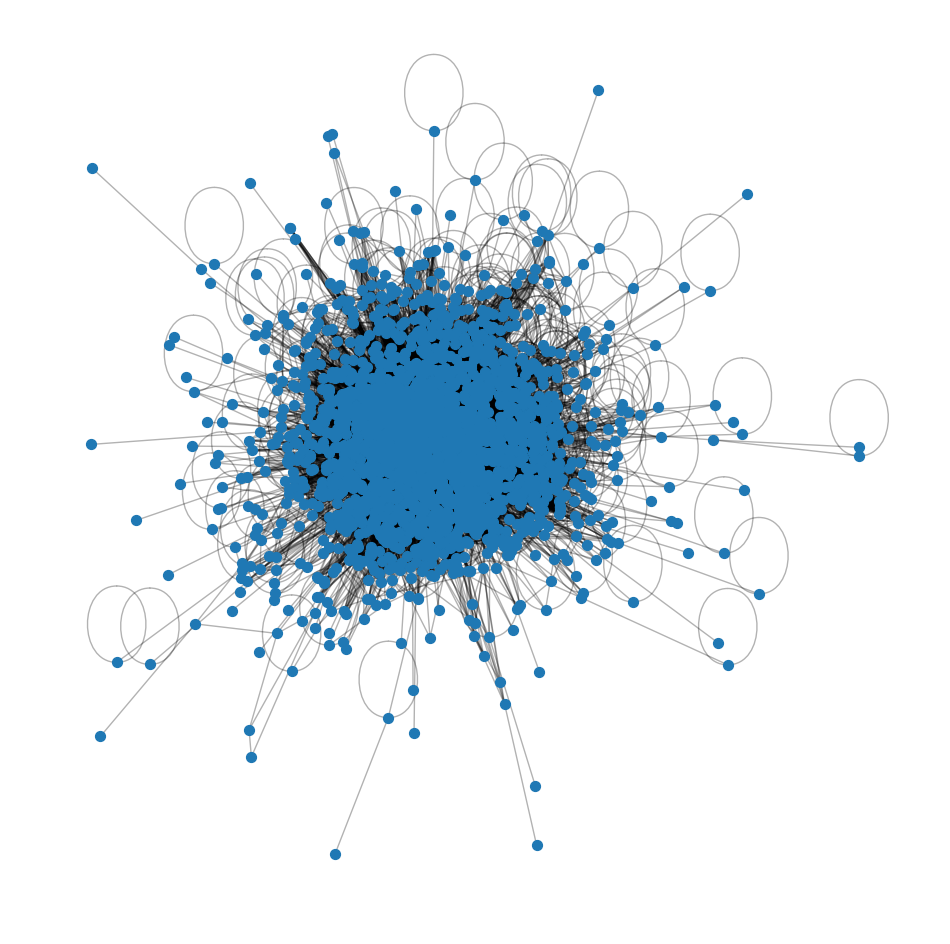

In [ ]:
pos = nx.spring_layout(G_lcc, seed=42)
plt.figure(figsize=(12, 12))

nx.draw_networkx_nodes(G_lcc, pos, node_size=50)
nx.draw_networkx_edges(G_lcc, pos, alpha=0.3)

plt.axis("off")
plt.show()

In [ ]:
G_lcc.edges()

EdgeView([('Q66107', 'Q719808'), ('Q66107', 'Q313411'), ('Q66107', 'Q298793'), ('Q66107', 'Q24313'), ('Q66107', 'Q1124'), ('Q66107', 'Q348163'), ('Q66107', 'Q373578'), ('Q66107', 'Q311269'), ('Q66107', 'Q959007'), ('Q66107', 'Q1175386'), ('Q66107', 'Q1365780'), ('Q66107', 'Q521427'), ('Q66107', 'Q207'), ('Q66107', 'Q368192'), ('Q66107', 'Q212648'), ('Q66107', 'Q6279'), ('Q66107', 'Q11153'), ('Q66107', 'Q359560'), ('Q66107', 'Q1334578'), ('Q66107', 'Q6294'), ('Q66107', 'Q355522'), ('Q66107', 'Q371315'), ('Q66107', 'Q48259'), ('Q66107', 'Q23685'), ('Q66107', 'Q15257'), ('Q66107', 'Q356069'), ('Q66107', 'Q456483'), ('Q66107', 'Q451808'), ('Q66107', 'Q1101308'), ('Q66107', 'Q1096555'), ('Q66107', 'Q456216'), ('Q66107', 'Q516594'), ('Q66107', 'Q17135'), ('Q66107', 'Q311562'), ('Q66107', 'Q446647'), ('Q66107', 'Q76'), ('Q66107', 'Q946305'), ('Q66107', 'Q499056'), ('Q66107', 'Q50612'), ('Q66107', 'Q359442'), ('Q66107', 'Q358443'), ('Q66107', 'Q4496'), ('Q66107', 'Q201795'), ('Q66107', 'Q17443